# Phase 9 — Risque, coûts, contraintes et observabilité

**Question de soutenance :** que voit un validateur lorsqu'il quitte le seul
ratio de Sharpe pour examiner trajectoire, drawdown, rotation, coûts, concentration
et comportement dégradé ?

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"
BRONZE = ROOT / "data" / "bronze"

def load_json(name):
    return json.loads((GOLD / name).read_text(encoding="utf-8"))

snapshot = load_json("snapshot_manifest.json")
assert snapshot["git_dirty"] is False, "Le snapshot source doit être propre."

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "equal_weight": "#94a3b8",
    "min_variance_lw": "#14b8a6",
    "max_sharpe": "#2563eb",
    "regime_conditional": "#f59e0b",
    "dcc_garch": "#0f766e",
    "rf_signal": "#8b5cf6",
    "xgb_signal": "#ef4444",
    "rf_signal_tuned": "#8b5cf6",
    "xgb_signal_tuned": "#ef4444",
}

display(Markdown(
    f"**Snapshot canonique :** `{snapshot['git_commit'][:12]}`  "
    f"— généré le `{snapshot['generated_at_utc']}` — arbre source propre."
))

**Snapshot canonique :** `ae87f48207d1`  — généré le `2026-08-09T02:32:55.411586+00:00` — arbre source propre.

In [2]:
equity_returns = pd.read_parquet(GOLD / "dashboard_equity.parquet")
equity_returns["Date"] = pd.to_datetime(equity_returns["Date"])
fit_summary = load_json("fit_report_summary.json")
fit_reports = pd.read_parquet(GOLD / "fit_reports.parquet")
crises = load_json("crisis_windows.json")
monitoring = load_json("monitoring_baseline.json")
currency = load_json("currency_manifest.json")

assert monitoring["status"] == "offline_on_demand_reference"

## Trajectoires nettes et drawdowns

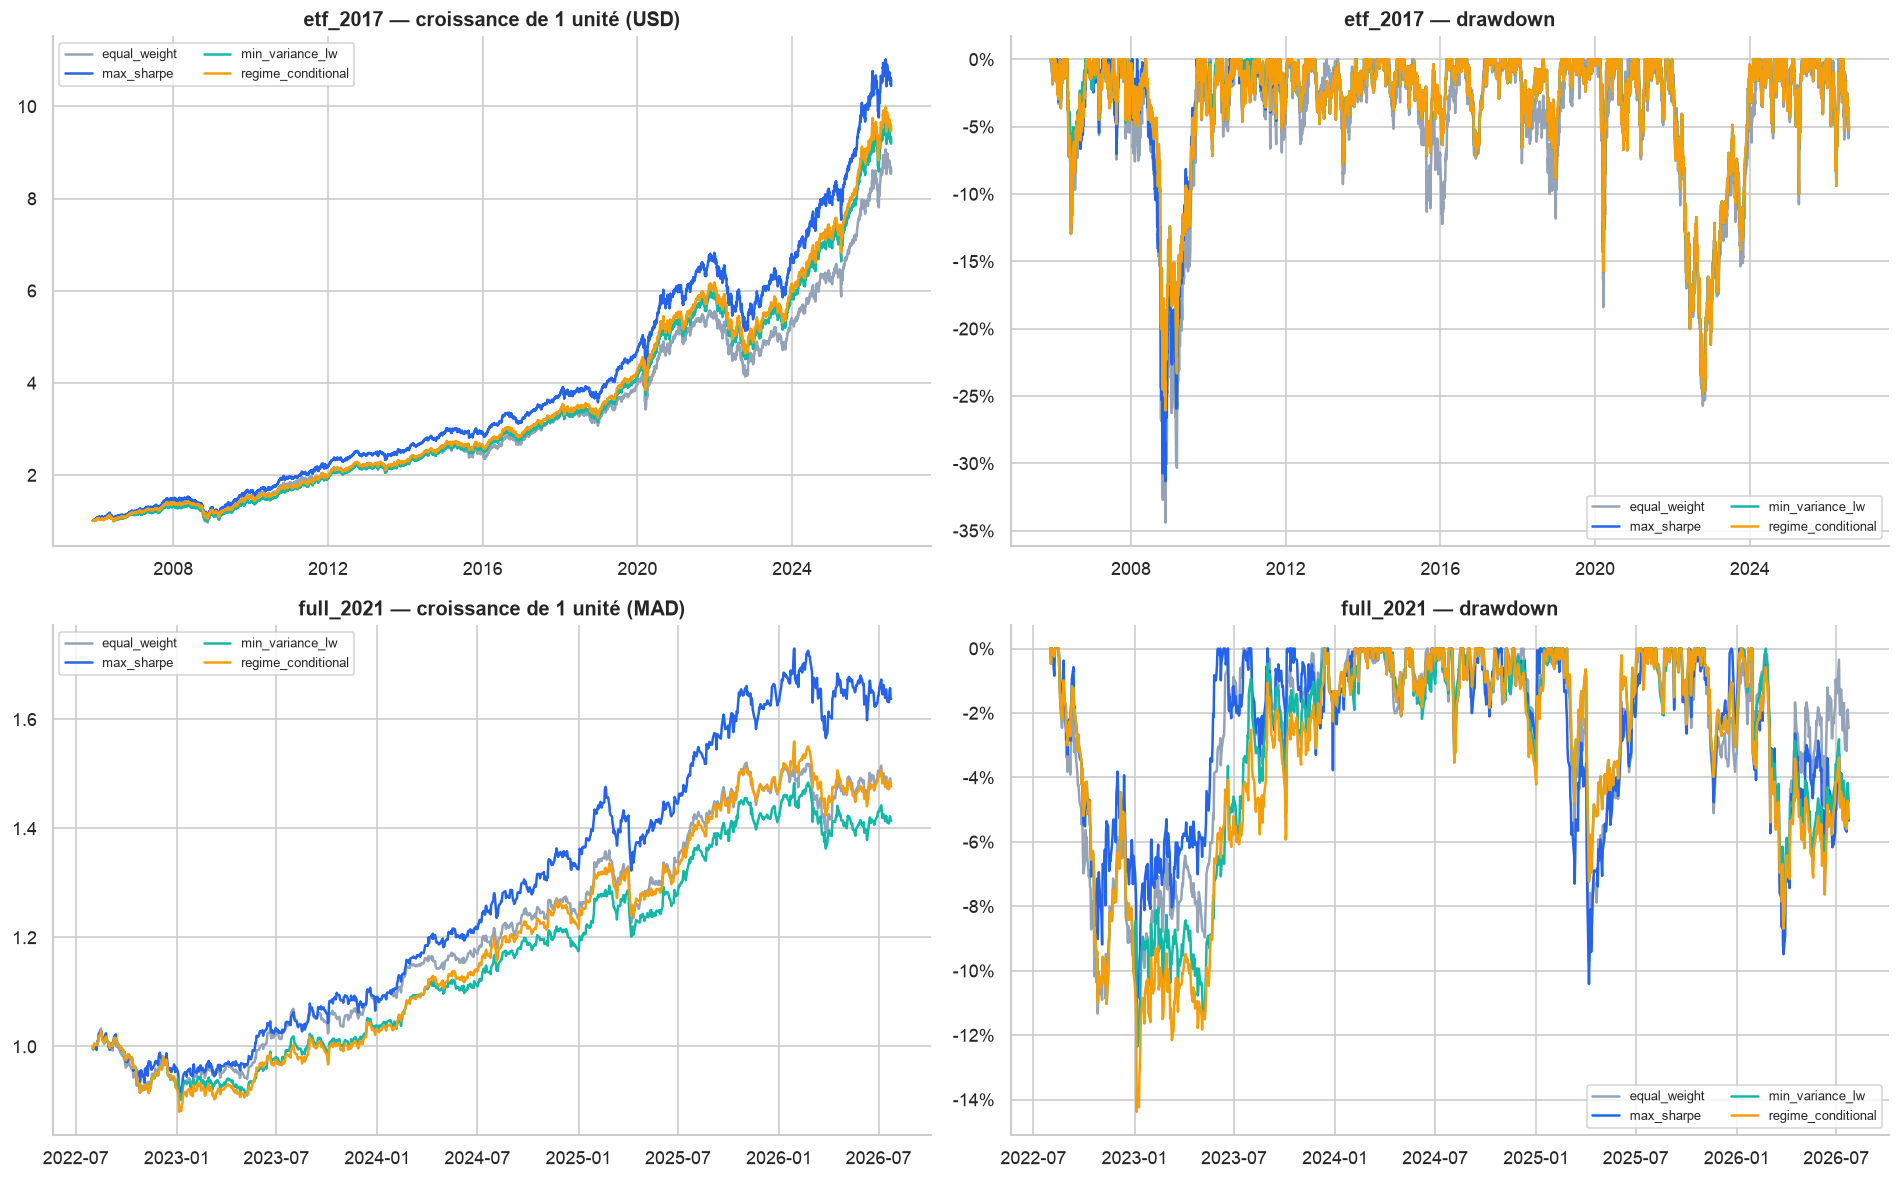

In [3]:
paths = equity_returns.sort_values(["universe", "strategy", "Date"]).copy()
paths["equity_net"] = paths.groupby(["universe", "strategy"])["net_return"].transform(lambda s: np.exp(s.cumsum()))
paths["drawdown"] = paths.groupby(["universe", "strategy"])["equity_net"].transform(lambda s: s / s.cummax() - 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, universe in enumerate(sorted(paths["universe"].unique())):
    frame = paths[paths["universe"].eq(universe)]
    for strategy, series in frame.groupby("strategy"):
        axes[row, 0].plot(series["Date"], series["equity_net"], label=strategy, color=COLORS.get(strategy))
        axes[row, 1].plot(series["Date"], series["drawdown"], label=strategy, color=COLORS.get(strategy))
    axes[row, 0].set_title(f"{universe} — croissance de 1 unité ({currency['universes'][universe]['base_currency']})")
    axes[row, 1].set_title(f"{universe} — drawdown")
    axes[row, 0].legend(ncol=2, fontsize=8)
    axes[row, 1].legend(ncol=2, fontsize=8)
    axes[row, 1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

## Rotation, coût et contrainte de poids

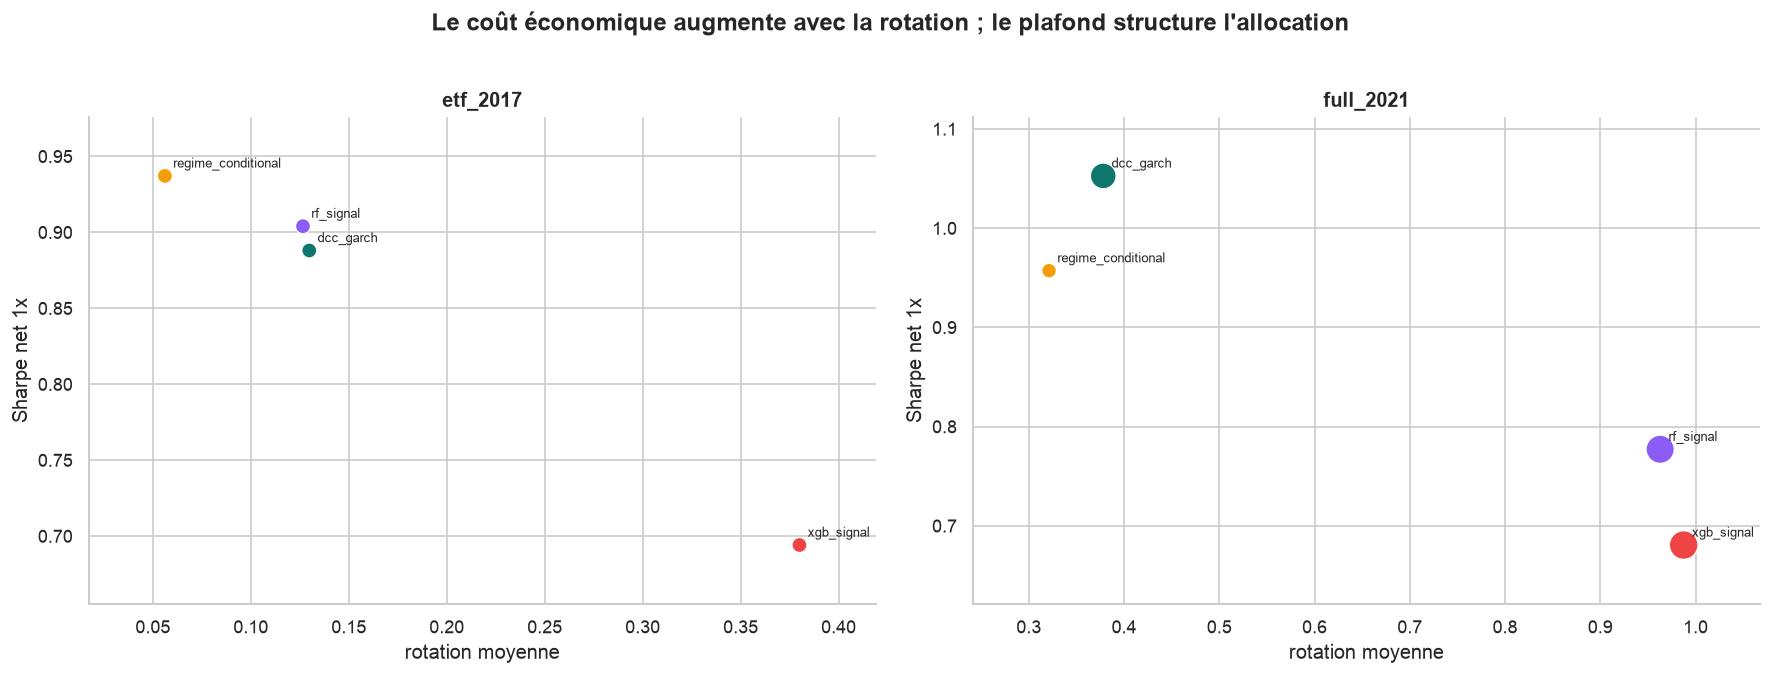

In [4]:
profile_rows = []
scenario_rows = []
for item in fit_summary["results"]:
    profile = item["execution_profile"]
    one_x = item["cost_sensitivity"]["scenarios"]["1x"]
    profile_rows.append({
        "univers": item["universe"],
        "stratégie": item["strategy_requested"],
        "Sharpe net 1x": one_x["net_sharpe"],
        "rotation moyenne": profile["avg_turnover"],
        "coût moyen (pb)": profile["avg_cost_drag_bps"],
        "dates avec plafond actif": profile["cap_binding_date_rate"],
        "allocation max": profile["max_allocation_observed"],
    })
    for label, scenario in item["cost_sensitivity"]["scenarios"].items():
        scenario_rows.append({
            "univers": item["universe"],
            "stratégie": item["strategy_requested"],
            "multiplicateur": scenario["cost_multiplier"],
            "Sharpe net": scenario["net_sharpe"],
            "rendement annualisé": scenario["annualized_return"],
        })
profiles = pd.DataFrame(profile_rows)
scenarios = pd.DataFrame(scenario_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (universe, frame) in zip(axes, profiles.groupby("univers", sort=True)):
    sns.scatterplot(data=frame, x="rotation moyenne", y="Sharpe net 1x", size="dates avec plafond actif", hue="stratégie", sizes=(80, 300), ax=ax, palette=COLORS, legend=False)
    for row in frame.itertuples(index=False):
        ax.annotate(row.stratégie, (getattr(row, "_3"), getattr(row, "_2")), xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.margins(x=0.12, y=0.16)
    ax.set_title(universe)
plt.suptitle("Le coût économique augmente avec la rotation ; le plafond structure l'allocation", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

display(profiles.set_index(["univers", "stratégie"]).style.format({
    "Sharpe net 1x": "{:.3f}",
    "rotation moyenne": "{:.3f}",
    "coût moyen (pb)": "{:.2f}",
    "dates avec plafond actif": "{:.1%}",
    "allocation max": "{:.1%}",
}))

## Sensibilité descriptive aux coûts

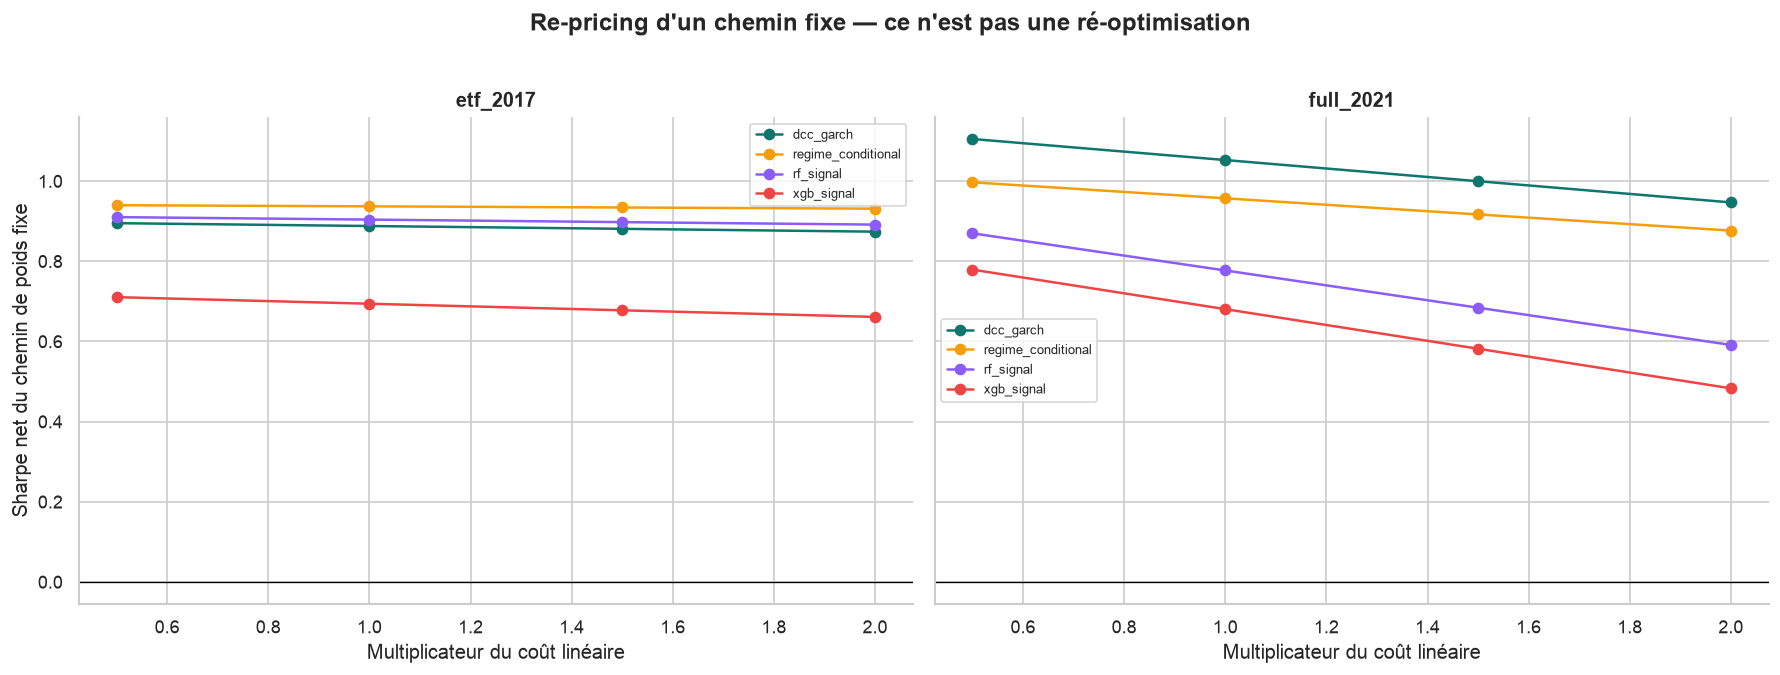

**Conditions de validité enregistrées dans l'artefact :**

- The weight path is held FIXED: no strategy evaluated here reads costs, so the same trades occur in every scenario.
- Costs are linear in traded notional. No market-impact or capacity term is modelled, so the drag scales exactly with the multiplier.
- NOT a re-optimization sensitivity analysis: it answers what these same trades would have cost, never what the strategy would have done had it known costs were higher.
- Does NOT apply to a turnover-penalized strategy (Phase 4C), where the cost of trading reaches the objective and higher costs would change the weights. Those scenarios must be re-simulated, not re-priced.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, (universe, frame) in zip(axes, scenarios.groupby("univers", sort=True)):
    for strategy, series in frame.groupby("stratégie"):
        series = series.sort_values("multiplicateur")
        ax.plot(series["multiplicateur"], series["Sharpe net"], marker="o", label=strategy, color=COLORS.get(strategy))
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(universe)
    ax.set_xlabel("Multiplicateur du coût linéaire")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Sharpe net du chemin de poids fixe")
plt.suptitle("Re-pricing d'un chemin fixe — ce n'est pas une ré-optimisation", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

validity = fit_summary["results"][0]["cost_sensitivity"]["validity_conditions"]
display(Markdown("**Conditions de validité enregistrées dans l'artefact :**\n\n" + "\n".join(f"- {item}" for item in validity)))

## Fenêtres de crise : drawdown par stratégie

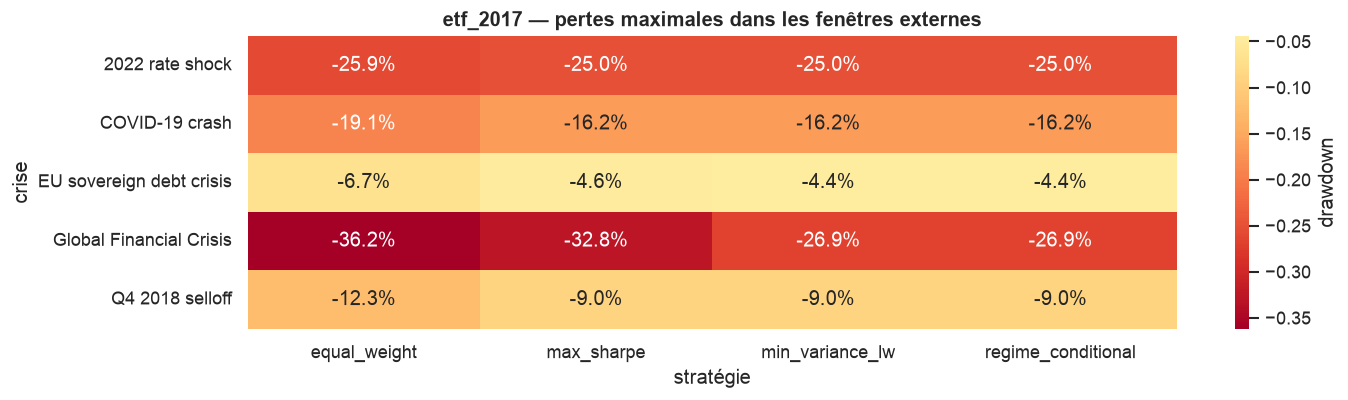

In [6]:
crisis_rows = []
for universe, windows in crises["universes"].items():
    for crisis_id, strategies in windows.items():
        for strategy, metrics in strategies.items():
            if metrics is not None:
                crisis_rows.append({
                    "univers": universe,
                    "crise": crises["crises"][crisis_id]["label"],
                    "stratégie": strategy,
                    "drawdown max": metrics["max_drawdown"],
                    "rendement": metrics["cum_return"],
                    "jours de reprise": metrics["recovery_days"],
                })
crisis_df = pd.DataFrame(crisis_rows)

for universe, frame in crisis_df.groupby("univers", sort=True):
    matrix = frame.pivot(index="crise", columns="stratégie", values="drawdown max")
    plt.figure(figsize=(12, max(3.5, 0.65 * len(matrix))))
    sns.heatmap(matrix, annot=True, fmt=".1%", cmap="RdYlGn", center=0, cbar_kws={"label": "drawdown"})
    plt.title(f"{universe} — pertes maximales dans les fenêtres externes")
    plt.tight_layout()
    plt.show()

## Intégrité des modèles : comportement demandé et comportement effectif

In [7]:
telemetry = (
    fit_reports.groupby(["universe", "strategy"], as_index=False)
    .agg(
        réallocations=("Date", "size"),
        fallbacks=("fit_status", lambda s: s.eq("fallback").sum()),
        avertissements=("fit_status", lambda s: s.eq("warning").sum()),
        modèles_effectifs=("model_effective", lambda s: ", ".join(sorted(set(s)))),
    )
)
telemetry["taux fallback"] = telemetry["fallbacks"] / telemetry["réallocations"]
display(telemetry.set_index(["universe", "strategy"]).style.format({"taux fallback": "{:.2%}"}))

total_fits = len(fit_reports)
total_fallbacks = fit_reports["fit_status"].eq("fallback").sum()
assert total_fallbacks == 0
display(Markdown(f"**Mesure versionnée : {total_fallbacks} fallback sur {total_fits} fits enregistrés.** Ce zéro décrit ce snapshot et ces stratégies ; il ne signifie pas que les chemins de repli sont impossibles."))

**Mesure versionnée : 0 fallback sur 1184 fits enregistrés.** Ce zéro décrit ce snapshot et ces stratégies ; il ne signifie pas que les chemins de repli sont impossibles.

## Monitoring : prêt pour contrôle à la demande, pas en production

In [8]:
monitor_rows = []
for universe, payload in monitoring["universes"].items():
    metrics = payload["metrics"]
    monitor_rows.append({
        "univers": universe,
        "fenêtre de référence": f"{payload['reference_window']['start']} → {payload['reference_window']['end']}",
        "fenêtre d'évaluation": f"{payload['evaluation_window_available']['start']} → {payload['evaluation_window_available']['end']}",
        "rotation moyenne": metrics["turnover"]["mean"],
        "part bear": metrics["regime_share"].get("bear", np.nan),
        "plafond actif": metrics["cap_binding"]["date_rate"],
    })
display(pd.DataFrame(monitor_rows).set_index("univers").style.format({"rotation moyenne": "{:.3f}", "part bear": "{:.1%}", "plafond actif": "{:.1%}"}))
display(Markdown(f"**Statut :** `{monitoring['status']}`. {monitoring['operational_note']}"))

,fenêtre de référence,fenêtre d'évaluation,rotation moyenne,part bear,plafond actif
univers,,,,,
etf_2017,2004-11-19 → 2018-12-21,2018-12-24 → 2026-07-24,0.038,33.1%,100.0%
full_2021,2021-07-30 → 2024-10-25,2024-10-28 → 2026-07-24,0.290,51.9%,77.8%


**Statut :** `offline_on_demand_reference`. Reference distributions for an OFFLINE, ON-DEMAND drift check. No live schedule is active; drift alerts, retraining triggers and incident response are not operational. Monitoring emits warnings and never alters model behaviour.

### Ce que ce notebook établit

- Les performances sont accompagnées de trajectoires, drawdowns, rotation et coûts.
- Le coût est une revalorisation linéaire d'un chemin de poids fixe, avec limites explicites.
- Aucun label publié ne cache un fallback sur le snapshot mesuré.
- Les références de monitoring existent pour un contrôle hors ligne à la demande.

### Ce qu'il n'établit pas

- Il n'existe ni monitoring live, ni exécution d'ordres, ni mesure de capacité/impact de marché.
- Un scénario de coûts n'est pas une preuve de robustesse économique.
- Le prototype reste non consultatif et hors production.